# Visual Analytics for Trustworthy GeoAI

## Uncertainty in Spatial Data 🗿

Spatial data are the samples from the real world **with unknown process and patterns**. The uncertainty of data can originate from several sources:
1. The imbalanced sampling of spatial data in different regions.
2. The incompleteness of spatial data in different regions.
3. The **MAUP** of spatial data

We will explore the uncertainty in spatial data from the three aspects.

*MAUP: Modifiable area unit problem

In [ ]:
# Load data from GitHub if not already cached locally
import os, urllib.request
import pandas as pd

REPO = "Vezarachan/TUM_Course_SVA_TrustGeoAI"
BRANCH = "main"
FILES = ["data/eurosat_metadata.parquet"]

for path in FILES:
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{path}"
        urllib.request.urlretrieve(url, path)
        print(f"✓ downloaded {path}")
    else:
        print(f"✓ cached    {path}")


✓ downloaded data/eurosat_metadata.parquet


In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd

### Imbalanced sampling of spatial data - It is not equal!

In [ ]:
eurosat_metadata = pd.read_parquet("data/eurosat_metadata.parquet")

In [ ]:
NATURALEARTH_URL = (
    "https://naciscdn.org/naturalearth/110m/cultural/"
    "ne_110m_admin_0_countries.zip"
)

In [ ]:
countries = gpd.read_file(NATURALEARTH_URL)
europe = countries.cx[-25:45, 35:72]

Visualize the spatial distribution of samples with counts by country

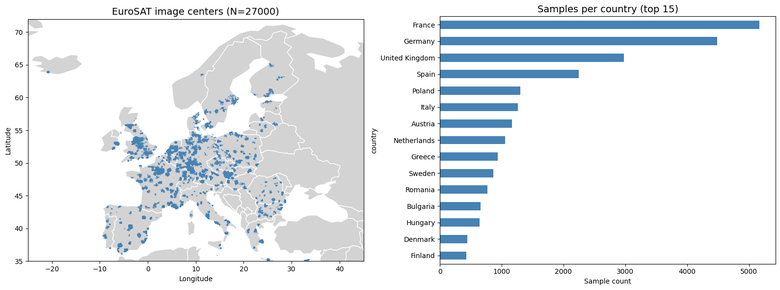

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
europe.plot(ax=axes[0], color='lightgrey', edgecolor='white')
axes[0].scatter(eurosat_metadata['lon'], eurosat_metadata['lat'], s=1, alpha=0.3, c='steelblue')
axes[0].set_xlim(-25, 45)
axes[0].set_ylim(35, 72)
axes[0].set_title(f"EuroSAT image centers (N={len(eurosat_metadata)})", fontsize=14)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# Aggregate data sources by country
top_countries = eurosat_metadata["country"].value_counts().head(15)
top_countries.sort_values().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Samples per country (top 15)", fontsize=14)
axes[1].set_xlabel("Sample count")

plt.tight_layout()
plt.show()

In [ ]:
country_count = eurosat_metadata["country"].value_counts()

In [ ]:
europe['samples_number'] = europe['NAME'].map(country_count)
europe['samples_number'] = europe['samples_number'].fillna(0)

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Visualze sample number per country

<Axes: >

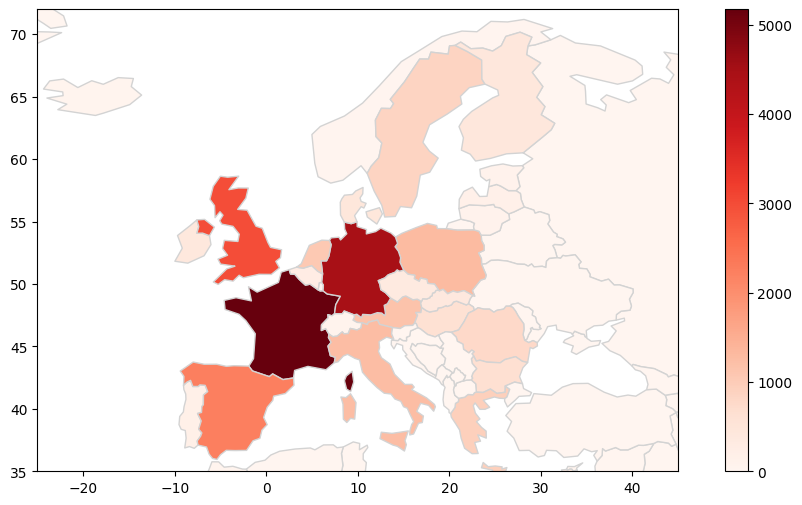

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.set_xlim(-25, 45)
ax.set_ylim(35, 72)
europe.plot(ax=ax, column='samples_number', cmap='Reds', edgecolor='lightgrey', legend='True')

> ❓**Question:**

What will happen if we train models using data in Germany and apply to Norway? Can you guess the results?

[Your Answer]

### Incompleteness of spatial data - Where is my data?

In [ ]:
import os, urllib.request
import pandas as pd

REPO = "Vezarachan/TUM_Course_SVA_TrustGeoAI"
BRANCH = "main"
FILES = ["data/berlin_buildings.parquet",
         "data/hamburg_buildings.parquet",
         "data/muenchen_buildings.parquet",
         "data/frankfurt_buildings.parquet",
         "data/leipzig_buildings.parquet",
         "data/dresden_buildings.parquet",
         "data/deu_buildup.tif",
         "data/city_boundaries.parquet",
         "data/city_subdivisions.parquet"]

for path in FILES:
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{path}"
        urllib.request.urlretrieve(url, path)
        print(f"✓ downloaded {path}")
    else:
        print(f"✓ cached    {path}")

✓ downloaded data/berlin_buildings.parquet
✓ downloaded data/hamburg_buildings.parquet
✓ downloaded data/muenchen_buildings.parquet
✓ downloaded data/frankfurt_buildings.parquet
✓ downloaded data/leipzig_buildings.parquet
✓ downloaded data/dresden_buildings.parquet
✓ downloaded data/deu_buildup.tif
✓ downloaded data/city_boundaries.parquet
✓ downloaded data/city_subdivisions.parquet


In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from pathlib import Path

In [ ]:
DATA = Path("data")

PROJ = "EPSG:25832"
boundaries = gpd.read_parquet(DATA / "city_boundaries.parquet").to_crs(PROJ)
subdivs    = gpd.read_parquet(DATA / "city_subdivisions.parquet")

Visualize the spatial distribution of OSM building footprint

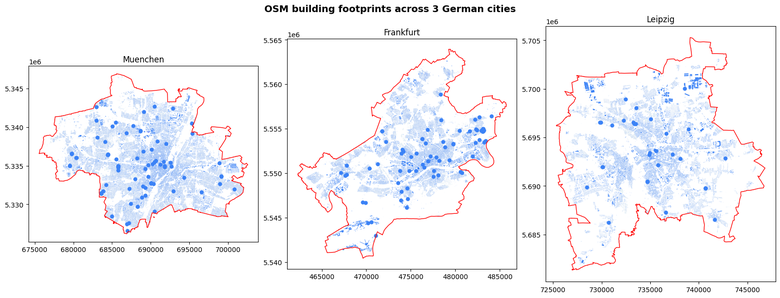

In [ ]:
 CITIES = ["muenchen", "frankfurt", "leipzig"]

fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

for i, (ax, city) in enumerate(zip(axes.flat, CITIES)):
    bnd = boundaries[boundaries.city == city]
    bld = gpd.read_parquet(DATA / f"{city}_buildings.parquet").to_crs(PROJ)

    bld.plot(ax=ax, color="#3b82f6", linewidth=0, rasterized=True)

    bnd.boundary.plot(ax=ax, color="red", linewidth=1.0)
    ax.set_title(CITIES[i].capitalize())

fig.suptitle(
    "OSM building footprints across 3 German cities",
    fontsize=14, fontweight="bold"
)
plt.show()

In [ ]:
CITIES = ["berlin", "hamburg", "muenchen", "frankfurt", "leipzig", "dresden"]

In [ ]:
def raster_built_m2(geom_series_in_raster_crs, src):
    """Sum GHSL pixel values inside a geometry. Each value already in m²."""
    clipped, _ = mask(src, geom_series_in_raster_crs, crop=True,
                      filled=True, nodata=0)
    return float(clipped[0].sum())

In [ ]:
city_rows = []
with rasterio.open(DATA / "deu_buildup.tif") as src:
    for city in CITIES:
        bnd = boundaries[boundaries.city == city].to_crs(src.crs)
        bld = gpd.read_parquet(DATA / f"{city}_buildings.parquet").to_crs(PROJ)

        raster_m2 = raster_built_m2(bnd.geometry, src)
        osm_m2    = float(bld.geometry.area.sum())
        city_rows.append({
            "city": city,
            "raster_built_km2": raster_m2 / 1e6,
            "osm_built_km2":    osm_m2 / 1e6,
            "completeness":     osm_m2 / raster_m2,
            "n_buildings":      len(bld),
        })

city_df = pd.DataFrame(city_rows).set_index("city")
print(city_df.round(3))

           raster_built_km2  osm_built_km2  completeness  n_buildings
city                                                                 
berlin              152.009        102.470         0.674       502677
hamburg             106.305         70.521         0.663       341903
muenchen             56.805         44.380         0.781       192143
frankfurt            38.726         25.284         0.653       127433
leipzig              40.448         24.143         0.597       108305
dresden              35.904         21.339         0.594        91079


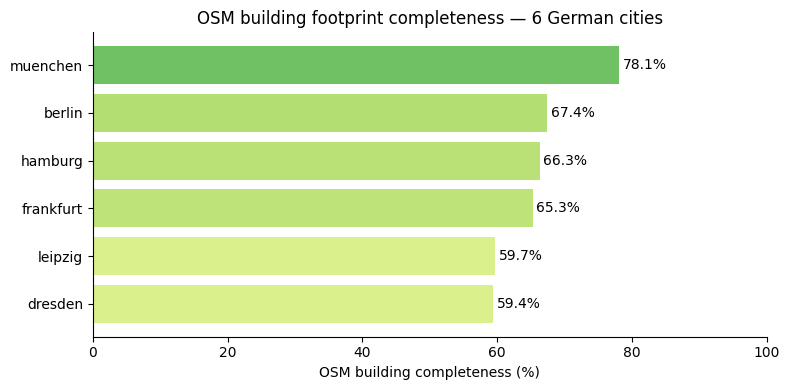

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ranked = city_df.sort_values("completeness")
colors = plt.cm.RdYlGn(ranked["completeness"].values)
ax.barh(ranked.index, ranked["completeness"] * 100, color=colors)
for y, v in enumerate(ranked["completeness"] * 100):
    ax.text(v + 0.5, y, f"{v:.1f}%", va="center", fontsize=10)
ax.set_xlabel("OSM building completeness (%)")
ax.set_xlim(0, 100)
ax.set_title("OSM building footprint completeness — 6 German cities")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
bezirk_rows = []
with rasterio.open(DATA / "deu_buildup.tif") as src:
    for city in CITIES:
        city_subs = subdivs[subdivs.city == city].to_crs(PROJ).copy()

        bld = gpd.read_parquet(DATA / f"{city}_buildings.parquet").to_crs(PROJ)
        bld["area_m2"] = bld.geometry.area

        # Attribute centroid of every building to Bezirk
        centroids = bld.set_geometry(bld.geometry.centroid)
        joined = gpd.sjoin(
            centroids[["area_m2", "geometry"]],
            city_subs[["name", "geometry"]],
            predicate="within", how="inner",
        )
        osm_per_bezirk = joined.groupby("name")["area_m2"].sum()

        # Compute the building area by Bezirk
        for _, b in city_subs.to_crs(src.crs).iterrows():
            r_m2 = raster_built_m2([b.geometry], src)
            o_m2 = float(osm_per_bezirk.get(b["name"], 0.0))
            bezirk_rows.append({
                "city": city,
                "bezirk": b["name"],
                "completeness": o_m2 / r_m2 if r_m2 > 0 else None,
            })

bezirk_df = pd.DataFrame(bezirk_rows)
bezirk_gdf = subdivs.merge(bezirk_df, on=["city", "name"],
                           left_on=None, right_on=None, how="left",
                           suffixes=("", "_x")).rename(columns={"name": "bezirk_name"})
# fallback merge by name
if "completeness" not in bezirk_gdf.columns:
    bezirk_gdf = subdivs.copy()
    bezirk_gdf["completeness"] = bezirk_gdf["name"].map(
        bezirk_df.set_index("bezirk")["completeness"]
    )

In [ ]:
bezirk_df = pd.DataFrame(bezirk_rows)
bezirk_df.columns = ["city", "name", "completeness"]
bezirk_gdf = subdivs.merge(bezirk_df, on=["city", "name"],
                           left_on=None, right_on=None, how="left",
                           suffixes=("", "_x")).rename(columns={"name": "bezirk_name"})
if "completeness" not in bezirk_gdf.columns:
    bezirk_gdf = subdivs.copy()
    bezirk_gdf["completeness"] = bezirk_gdf["bezirk"].map(
        bezirk_df.set_index("bezirk")["completeness"]
    )

bezirk_gdf['completeness'] = bezirk_gdf['completeness'] * 100.0

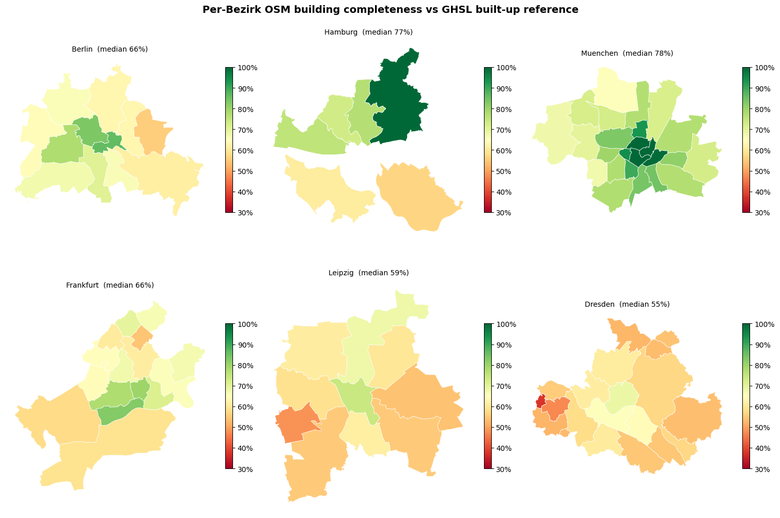

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
for ax, city in zip(axes.flat, CITIES):
    g = bezirk_gdf[bezirk_gdf.city == city].to_crs(PROJ)
    g.plot(ax=ax, column="completeness", cmap="RdYlGn",
           vmin=30, vmax=100, edgecolor="white", linewidth=0.5,
           legend=True, legend_kwds={"shrink": 0.6,  "format": "%.0f%%"})
    ax.set_title(f"{city.capitalize()}  "
                 f"(median {g['completeness'].median():.0f}%)",
                 fontsize=10)
    ax.set_axis_off()
fig.suptitle("Per-Bezirk OSM building completeness vs GHSL built-up reference",
             fontsize=14, fontweight="bold")
plt.show()



> ❓**Question:**
1. What insights do you find from the completeness of building footprints in Germany?
2. What results will this problem cause?
3. What is the difference between imbalanced sampling and incompleteness?



[Your Answer]

### The **MAUP** of spatial data - Totally different story by perspective

Modifiable Areal Unit Problem (MAUP) is an important topic discussed by people for a long time. It involves not only different spatial scale (e.g., county, state, zip code) but also the shape of spatial unit (e.g., grid, triangle, hexagon, or administrative regions). Depending on the spatial unit you select, you may tell a totally different story! (See figure below)

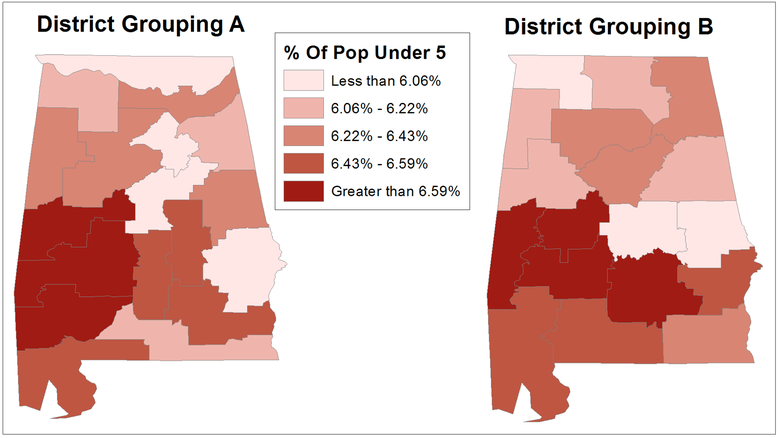

In [ ]:
import os, urllib.request
import pandas as pd

REPO = "Vezarachan/TUM_Course_SVA_TrustGeoAI"
BRANCH = "main"
FILES = ["data/us_election.gpkg"]   # add data

for path in FILES:
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{path}"
        urllib.request.urlretrieve(url, path)
        print(f"✓ downloaded {path}")
    else:
        print(f"✓ cached    {path}")

✓ downloaded data/us_election.gpkg


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

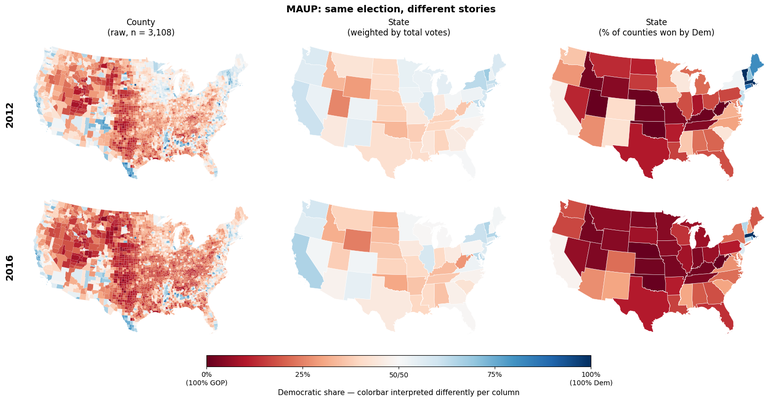

In [ ]:
PROJ = "EPSG:5070"
EXCLUDE = {"02", "15", "60", "66", "69", "72", "78"}

cnty = gpd.read_file("data/us_election.gpkg", layer="election")
cnty = cnty[~cnty["STATEFP"].isin(EXCLUDE)].to_crs(PROJ)

YEARS = [12, 16]
state_by_votes   = {}   # Aggregate by total votes
state_by_winners = {}   # Aggregate by wins

for y in YEARS:
    # Aggregation 1: population-weighted
    sv = cnty.dissolve(by="STATEFP", aggfunc={
        f"Demvotes{y}": "sum", f"GOPvotes{y}": "sum",
    })
    sv[f"pct_dem_{y}"] = sv[f"Demvotes{y}"] / (sv[f"Demvotes{y}"] + sv[f"GOPvotes{y}"])
    state_by_votes[y] = sv

    # Aggregation 2: county-counted, equal-weighted
    cnty[f"dem_won_{y}"] = (cnty[f"pct_dem_{y}"] > 0.5).astype(float)
    sw = cnty.dissolve(by="STATEFP", aggfunc={f"dem_won_{y}": "mean"})
    sw = sw.rename(columns={f"dem_won_{y}": f"pct_dem_{y}"})
    state_by_winners[y] = sw

fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
VMIN, VMAX, CMAP = 0.0, 1.0, "RdBu"

for i, y in enumerate(YEARS):
    cnty.plot(ax=axes[i, 0], column=f"pct_dem_{y}", cmap=CMAP,
              vmin=VMIN, vmax=VMAX, edgecolor="white", linewidth=0.05)
    state_by_votes[y].plot(ax=axes[i, 1], column=f"pct_dem_{y}", cmap=CMAP,
                           vmin=VMIN, vmax=VMAX, edgecolor="white", linewidth=0.4)
    state_by_winners[y].plot(ax=axes[i, 2], column=f"pct_dem_{y}", cmap=CMAP,
                             vmin=VMIN, vmax=VMAX, edgecolor="white", linewidth=0.4)

axes[0, 0].set_title(f"County\n(raw, n = {len(cnty):,})", fontsize=12)
axes[0, 1].set_title("State\n(weighted by total votes)", fontsize=12)
axes[0, 2].set_title("State\n(% of counties won by Dem)", fontsize=12)

for ax in axes.flat:
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_aspect("equal")

for i, y in enumerate(YEARS):
    axes[i, 0].set_ylabel(f"20{y}", fontsize=14, fontweight="bold",
                          rotation=90, labelpad=12)

sm = cm.ScalarMappable(cmap=CMAP, norm=Normalize(VMIN, VMAX))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal",
                    shrink=0.5, pad=0.04, aspect=35)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["0%\n(100% GOP)", "25%", "50/50", "75%",
                     "100%\n(100% Dem)"])
cbar.set_label("Democratic share — colorbar interpreted differently per column",
               fontsize=11)

fig.suptitle("MAUP: same election, different stories",
             fontsize=14, fontweight="bold")
plt.show()

**For the election in the year 2016, if we aggregate by number of votes, then Hillary and Trump are evenly matched. In contrast, if we aggregate by the number of county wins, then Trump wins overwelmingly.**

> ❓**Question:**

1. What can you find by comparing county-level and state-level visualization?
2. What reason could it be to cause very different stories?

[Your answer]